In [34]:
# STEP 4: Create Dataset

import pandas as pd
import numpy as np

# set seed for reproducibility
np.random.seed(42)

# number of rows
n = 10000

# generate data
price = np.random.randint(50, 200, n)
discount = np.random.randint(0, 30, n)
competitor_price = price + np.random.randint(-20, 20, n)
marketing_spend = np.random.randint(1000, 10000, n)

season = np.random.choice(['Summer', 'Winter', 'Festival'], n)
region = np.random.choice(['North', 'South', 'East', 'West'], n)

# demand logic (important)
units_sold = (
    200 
    - (price * 0.8) 
    + (discount * 2) 
    + (marketing_spend * 0.01)
    + np.random.normal(0, 10, n)
)

# convert to positive values
units_sold = np.maximum(units_sold, 10)

# create dataframe
df = pd.DataFrame({
    'price': price,
    'units_sold': units_sold.astype(int),
    'discount': discount,
    'competitor_price': competitor_price,
    'marketing_spend': marketing_spend,
    'season': season,
    'region': region
})

# save dataset
df.to_csv('../data/raw_data.csv', index=False)
df.head(10)

,price,units_sold,discount,competitor_price,marketing_spend,season,region
0,152,119,11,150,2429,Winter,East
1,142,148,15,128,3962,Winter,North
2,64,281,28,48,8386,Festival,East
3,156,151,24,175,3468,Festival,East
4,121,178,20,121,4228,Winter,South
5,70,264,17,56,9320,Summer,East
6,152,129,2,168,5399,Winter,West
7,171,147,19,173,4966,Summer,West
8,124,201,14,114,6281,Festival,South
9,137,147,4,126,6017,Summer,West


In [35]:
# STEP 5: Inspect Data

# 1. Shape
print(df.shape)

# 2. Data Types
print(df.dtypes)

# 3. Missing Values
print(df.isnull())
print(df.sum())

# 4. Basic Statistics
print(df.describe())

(10000, 7)
price               int32
units_sold          int64
discount            int32
competitor_price    int32
marketing_spend     int32
season                str
region                str
dtype: object
      price  units_sold  discount  competitor_price  marketing_spend  season  \
0     False       False     False             False            False   False   
1     False       False     False             False            False   False   
2     False       False     False             False            False   False   
3     False       False     False             False            False   False   
4     False       False     False             False            False   False   
...     ...         ...       ...               ...              ...     ...   
9995  False       False     False             False            False   False   
9996  False       False     False             False            False   False   
9997  False       False     False             False            False   Fa

In [40]:
# STEP 6: Clean Data

import pandas as pd

# load data
df = pd.read_csv('../data/raw_data.csv')

# 1. Check missing values
print(df.isnull().sum())

# handle missing values (if any)
df = df.ffill()

# 2. Remove duplicates
df = df.drop_duplicates()

# 3. Fix incorrect values
# price and units_sold should not be negative
df = df[df['price'] > 0]
df = df[df['units_sold'] > 0]

# 4. (Optional) Feature check
# season already exists, so no need to recreate unless missing

# save cleaned data
df.to_csv('../data/cleaned_data.csv', index=False)

df.head()

price               0
units_sold          0
discount            0
competitor_price    0
marketing_spend     0
season              0
region              0
dtype: int64


,price,units_sold,discount,competitor_price,marketing_spend,season,region
0,152,119,11,150,2429,Winter,East
1,142,148,15,128,3962,Winter,North
2,64,281,28,48,8386,Festival,East
3,156,151,24,175,3468,Festival,East
4,121,178,20,121,4228,Winter,South


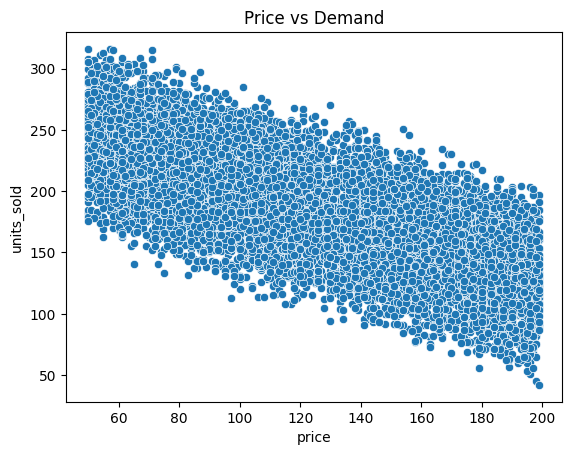

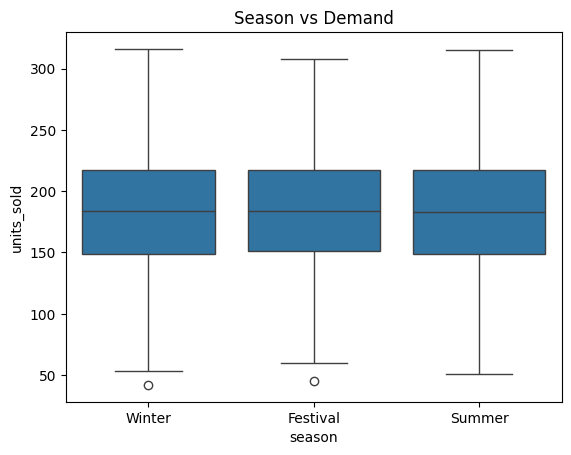

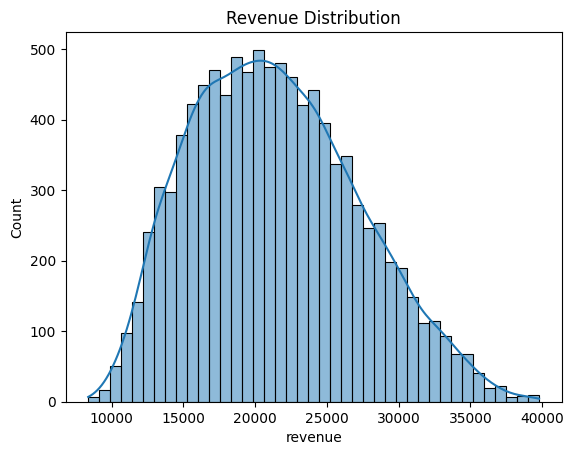

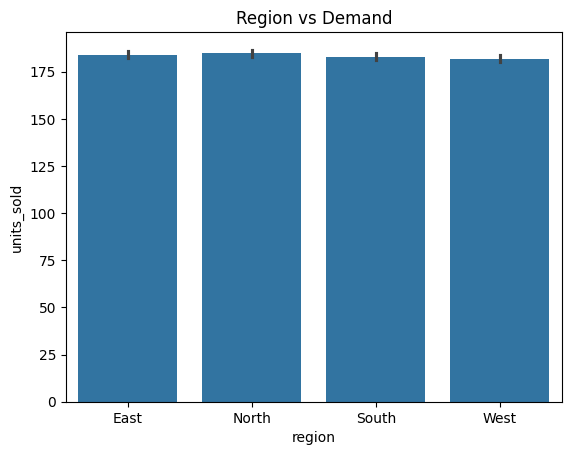

In [41]:
# STEP 7: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')

# create revenue column
df['revenue'] = df['price'] * df['units_sold']

# 1. Price vs Demand
plt.figure()
sns.scatterplot(x='price', y='units_sold', data=df)
plt.title("Price vs Demand")
plt.show()

# 2. Seasonal Trends
plt.figure()
sns.boxplot(x='season', y='units_sold', data=df)
plt.title("Season vs Demand")
plt.show()

# 3. Revenue Patterns
plt.figure()
sns.histplot(df['revenue'], kde=True)
plt.title("Revenue Distribution")
plt.show()

# 4. Region-wise Behavior
plt.figure()
sns.barplot(x='region', y='units_sold', data=df)
plt.title("Region vs Demand")
plt.show()

In [42]:
# STEP 8: Demand Elasticity Analysis

import pandas as pd

df = pd.read_csv('../data/cleaned_data.csv')

# correlation
correlation = df['price'].corr(df['units_sold'])
print("Correlation between Price and Demand:", correlation)

Correlation between Price and Demand: -0.7308265008965662


In [43]:
import numpy as np
import statsmodels.api as sm

# take log
df['log_price'] = np.log(df['price'])
df['log_demand'] = np.log(df['units_sold'])

# model
X = sm.add_constant(df['log_price'])
y = df['log_demand']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     9252.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:17:00   Log-Likelihood:                 1773.1
No. Observations:               10000   AIC:                            -3542.
Df Residuals:                    9998   BIC:                            -3528.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.5992      0.025    300.564      0.0

In [44]:
# STEP 9: Feature Engineering

# load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')

# 1. Price difference vs competitor
df['price_diff'] = df['price'] - df['competitor_price']

# 2. Discount percentage (safe calculation)
df['discount_pct'] = (df['discount'] / df['price']) * 100

# 3. Seasonal flags (one-hot encoding)
df = pd.get_dummies(df, columns=['season'], drop_first=True)

# 4. Region encoding (optional but recommended)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# save engineered data
df.to_csv('../data/feature_engineered_data.csv', index=False)

df.head()

,price,units_sold,discount,competitor_price,marketing_spend,price_diff,discount_pct,season_Summer,season_Winter,region_North,region_South,region_West
0,152,119,11,150,2429,2,7.236842,False,True,False,False,False
1,142,148,15,128,3962,14,10.563380,False,True,True,False,False
2,64,281,28,48,8386,16,43.750000,False,False,False,False,False
3,156,151,24,175,3468,-19,15.384615,False,False,False,False,False
4,121,178,20,121,4228,0,16.528926,False,True,False,True,False


In [45]:
# Step 10: Build Predictive Model

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# load data
df = pd.read_csv('../data/feature_engineered_data.csv')

# define features and target
X = df.drop(columns=['units_sold'])
y = df['units_sold']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# 2. Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

# predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("Models trained successfully")

Models trained successfully


In [47]:
# STEP 11: Model Evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Linear Regression Evaluation
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression:")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

# Random Forest Evaluation
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest:")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)

Linear Regression:
RMSE: 9.73811393273744
MAE: 7.818659355014777
R2 Score: 0.9584370685395684

Random Forest:
RMSE: 10.643061826842874
MAE: 8.541015
R2 Score: 0.9503533855047885


In [49]:
# STEP 12–14: Price Simulation + Revenue + Optimization

import pandas as pd
import numpy as np

# =========================
# Load Data
# =========================
df = pd.read_csv('../data/feature_engineered_data.csv')

# =========================
# Prepare Features (same as training)
# =========================
X = df.drop(columns=['units_sold'])

# Save feature columns (VERY IMPORTANT)
feature_cols = X.columns

# =========================
# Take one sample row
# =========================
sample = df.iloc[0].copy()

# =========================
# Generate Price Range
# =========================
price_range = np.arange(50, 200, 5)

results = []

# =========================
# Simulation Loop
# =========================
for price in price_range:
    
    temp = sample.copy()
    
    # update price
    temp['price'] = price
    
    # update engineered features
    temp['price_diff'] = price - temp['competitor_price']
    temp['discount_pct'] = (temp['discount'] / price) * 100
    
    # convert to dataframe
    temp_df = pd.DataFrame([temp])
    
    # ❗ IMPORTANT FIXES
    # remove target column
    temp_df = temp_df.drop(columns=['units_sold'], errors='ignore')
    
    # match training columns
    temp_df = temp_df[feature_cols]
    
    # prediction (use your best model, e.g., rf)
    predicted_demand = rf.predict(temp_df)[0]
    
    # revenue calculation
    revenue = price * predicted_demand
    
    results.append([price, predicted_demand, revenue])

# =========================
# Create Results DataFrame
# =========================
result_df = pd.DataFrame(results, columns=['price', 'predicted_demand', 'revenue'])

# =========================
# Find Optimal Price
# =========================
optimal_row = result_df.loc[result_df['revenue'].idxmax()]

print("✅ Optimal Price:", optimal_row['price'])
print("💰 Maximum Revenue:", optimal_row['revenue'])

# =========================
# Show Top Results
# =========================
print(result_df.head())

✅ Optimal Price: 130.0
💰 Maximum Revenue: 18925.4
   price  predicted_demand   revenue
0     50            205.35  10267.50
1     55            198.80  10934.00
2     60            196.00  11760.00
3     65            196.17  12751.05
4     70            191.16  13381.20


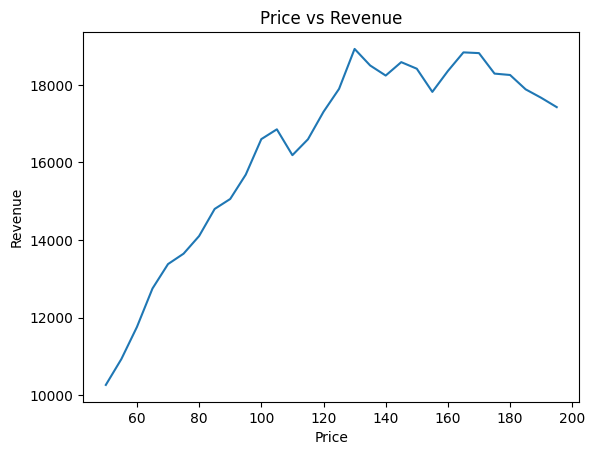

In [50]:
import matplotlib.pyplot as plt

plt.plot(result_df['price'], result_df['revenue'])
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title("Price vs Revenue")
plt.show()